# Clean the data

In [3]:
import os
import pandas as pd
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

load_dotenv()

engine = create_engine(os.getenv("DATABASE_URL"))

## Load the dataset

In [4]:
with engine.connect() as conn:
    df = pd.read_sql("SELECT * FROM ohlcv WHERE ticker = '^GSPC'", con=conn)

## Exploration

In [6]:
df.shape

(24654, 9)

In [7]:
df.dtypes

ticker                          str
timestamp       datetime64[us, UTC]
open                        float64
high                        float64
low                         float64
close                       float64
volume                        int64
dividends                   float64
stock_splits                float64
dtype: object

In [9]:
df.tail(5)

,ticker,timestamp,open,high,low,close,volume,dividends,stock_splits
24649,^GSPC,2026-02-19 05:00:00+00:00,6861.339844,6879.120117,6833.060059,6861.890137,5151690000,0.0,0.0
24650,^GSPC,2026-02-20 05:00:00+00:00,6843.259766,6915.859863,6836.330078,6909.509766,5432480000,0.0,0.0
24651,^GSPC,2026-02-23 05:00:00+00:00,6901.250000,6916.959961,6819.819824,6837.750000,5638350000,0.0,0.0
24652,^GSPC,2026-02-24 05:00:00+00:00,6837.370117,6899.169922,6815.430176,6890.069824,5266090000,0.0,0.0
24653,^GSPC,2026-02-25 05:00:00+00:00,6915.149902,6952.509766,6915.149902,6946.129883,5328060000,0.0,0.0


## Handle Missing Values

In [12]:
df.isnull().sum()

ticker          0
timestamp       0
open            0
high            0
low             0
close           0
volume          0
dividends       0
stock_splits    0
dtype: int64

In [13]:
df.isnull().mean() * 100

ticker          0.0
timestamp       0.0
open            0.0
high            0.0
low             0.0
close           0.0
volume          0.0
dividends       0.0
stock_splits    0.0
dtype: float64

In [15]:
df = df.drop(columns=['ticker'])

In [ ]:
## Plot the data

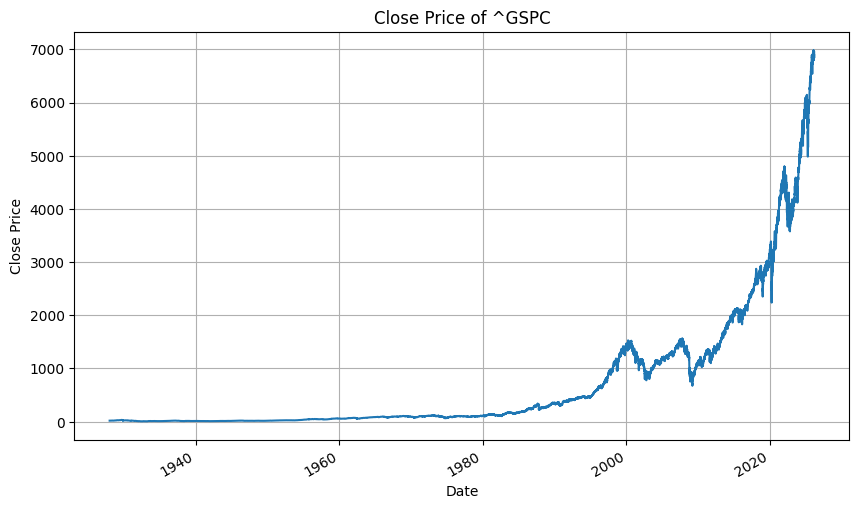

In [24]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
from datetime import datetime

# df.set_index('timestamp', inplace=True)

plt.figure(figsize=(10, 6))

plt.plot(df.index, df['close'])

plt.title("Close Price of ^GSPC")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.grid(True)

plt.gcf().autofmt_xdate()

plt.show()